# T1 · What a physics-informed neural network actually is

A neural network is usually trained to match **data**. A PINN is trained to
satisfy an **equation**. That is the whole idea, and everything else is
consequence.

We will solve

$$\frac{d^2x}{dt^2} = -\omega^2 x, \qquad x(0) = 1, \quad \dot{x}(0) = 0$$

whose answer is $x(t) = \cos(\omega t)$, so we ca# T1 · What a physics-informed neural network actually is

A neural network is usually trained to match **data**. A PINN is trained to
satisfy an **equation**. That is the whole idea, and everything else is
consequence.

We will solve

$$\frac{d^2x}{dt^2} = -\omega^2 x, \qquad x(0) = 1, \quad \dot{x}(0) = 0$$

whose answer is $x(t) = \cos(\omega t)$, so we can check every step against
something known. **There is no training data anywhere in this notebook.**n check every step against
something known. **There is no training data anywhere in this notebook.**

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, torch, matplotlib.pyplot as plt
from physprior.viz import plots as P
P.use_style()
torch.set_default_dtype(torch.float64)
print("torch", torch.__version__)

torch 2.11.0


## Step 1 · The network is the solution

Write $x_\theta(t)$: a small network taking a time and returning a position.
Not a fit to samples of the solution; the network *is* the candidate
solution, and training will push it toward obeying the ODE.

In [2]:
def mlp(width=32, depth=3):
    layers = [torch.nn.Linear(1, width), torch.nn.Tanh()]
    for _ in range(depth - 1):
        layers += [torch.nn.Linear(width, width), torch.nn.Tanh()]
    return torch.nn.Sequential(*layers, torch.nn.Linear(width, 1))

torch.manual_seed(0)
net = mlp()
print(net)
print("parameters:", sum(p.numel() for p in net.parameters()))

Sequential(
  (0): Linear(in_features=1, out_features=32, bias=True)
  (1): Tanh()
  (2): Linear(in_features=32, out_features=32, bias=True)
  (3): Tanh()
  (4): Linear(in_features=32, out_features=32, bias=True)
  (5): Tanh()
  (6): Linear(in_features=32, out_features=1, bias=True)
)
parameters: 2209


### Why `tanh` and never `ReLU`

The loss will differentiate the network's output **twice**. A ReLU network is
piecewise linear, so its second derivative is zero almost everywhere and the
physics term would be identically zero. This is not a style preference: a
ReLU PINN on a second-order equation silently trains on nothing.

In [3]:
relu_net = torch.nn.Sequential(torch.nn.Linear(1, 8), torch.nn.ReLU(), torch.nn.Linear(8, 1))
t = torch.linspace(0, 1, 5, requires_grad=True)
for name, f in (("tanh", net), ("relu", relu_net)):
    y = f(t.unsqueeze(-1)).squeeze(-1)
    dy = torch.autograd.grad(y.sum(), t, create_graph=True)[0]
    d2y = torch.autograd.grad(dy.sum(), t, create_graph=True)[0]
    print(f"{name}: second derivative = {d2y.detach().numpy().round(6)}")

tanh: second derivative = [-0.021865 -0.023681 -0.018253 -0.008098  0.001936]
relu: second derivative = [0. 0. 0. 0. 0.]


## Step 2 · The initial conditions, as a hard constraint

Two ways to impose $x(0)=1,\ \dot x(0)=0$:

* **soft**: add $\lambda\,[(x_\theta(0)-1)^2 + \dot x_\theta(0)^2]$ to the
  loss. Now there is a weight $\lambda$ to tune, and the conditions hold only
  approximately.
* **hard**: build them into the architecture:

$$x_\theta(t) = 1 + t^2\,\mathrm{NN}(t)$$

At $t=0$ this is exactly 1, and its derivative is exactly 0, for *any*
network. No weight, no approximation. **Prefer hard constraints wherever the
algebra allows them**; it is one fewer hyperparameter nobody can justify.

In [4]:
def x_hard(t, f=None):
    f = net if f is None else f
    return 1.0 + t**2 * f(t.unsqueeze(-1)).squeeze(-1)

t0 = torch.zeros(1, requires_grad=True)
x0 = x_hard(t0)
v0 = torch.autograd.grad(x0.sum(), t0, create_graph=True)[0]
print(f"x(0) = {float(x0):.12f}   (want 1)")
print(f"x'(0) = {float(v0):.12f}   (want 0)")
print("both exact, before any training")

x(0) = 1.000000000000   (want 1)
x'(0) = 0.000000000000   (want 0)
both exact, before any training


## Step 3 · Collocation points and the residual

The physics loss is evaluated at **collocation points**: times we choose,
where we ask whether the equation holds. They are not data: nothing is known
about the solution there. They are just where we check.

$$\mathcal{L} = \frac{1}{N}\sum_i \left[\ddot x_\theta(t_i) + \omega^2 x_\theta(t_i)\right]^2$$

In [5]:
OMEGA = 2.0

def residual(t, f=None):
    t = t.requires_grad_(True)
    x = x_hard(t, f)
    dx = torch.autograd.grad(x.sum(), t, create_graph=True)[0]
    d2x = torch.autograd.grad(dx.sum(), t, create_graph=True)[0]
    return d2x + OMEGA**2 * x

t_colloc = torch.linspace(0, 3, 200)
print("collocation points:", len(t_colloc))
print("residual before training (should be large):",
      float(torch.mean(residual(t_colloc.clone())**2)))

collocation points: 200
residual before training (should be large): 7.652137034111317


## Step 4 · Train, and watch it obey the equation

In [6]:
opt = torch.optim.Adam(net.parameters(), lr=5e-3)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=3000)
history = []
for epoch in range(3000):
    opt.zero_grad()
    loss = torch.mean(residual(t_colloc.clone())**2)
    loss.backward(); opt.step(); sched.step()
    if epoch % 100 == 0:
        history.append((epoch, float(loss)))
print(f"final residual loss: {float(loss):.3e}")

final residual loss: 3.435e-03


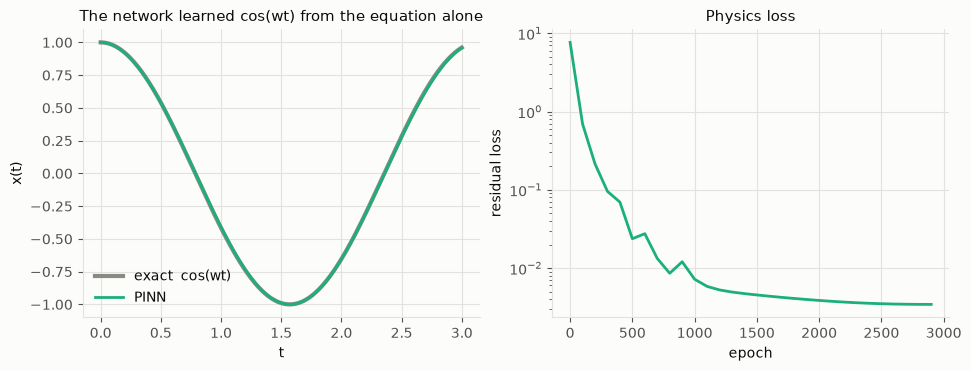

max |error| over the interval: 9.00e-03


In [7]:
grid = torch.linspace(0, 3, 400)
with torch.no_grad():
    learned = x_hard(grid).numpy()
truth = np.cos(OMEGA * grid.numpy())

fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.6))
axes[0].plot(grid, truth, lw=3, color=P.INK_MUTED, label="exact  cos(wt)")
axes[0].plot(grid, learned, color=P.ARM_COLOR["pinn"], label="PINN")
axes[0].set_xlabel("t"); axes[0].set_ylabel("x(t)"); axes[0].legend()
axes[0].set_title("The network learned cos(wt) from the equation alone")
e, l = zip(*history)
axes[1].semilogy(e, l, color=P.ARM_COLOR["pinn"])
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("residual loss")
axes[1].set_title("Physics loss")
plt.show()
print(f"max |error| over the interval: {np.max(np.abs(learned - truth)):.2e}")

## What just happened

The network never saw a single value of $\cos$. It was handed an equation,
some points at which to satisfy it, and initial conditions it could not
violate, and it produced the solution.

**This is the forward problem**: the law is fully known and we want the
solution. It is also the case where a PINN is *least* competitive: a standard
ODE integrator solves this in microseconds to machine precision, while the
network took thousands of epochs to reach ~1e-3.

So why use one? Because the same machinery does something integrators cannot,
which is the subject of [T2](T2_forward_and_inverse.ipynb): **recovering
unknown constants in the equation from sparse, noisy measurements**.